In [105]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [106]:
class TwoStageCIC:
    def __init__(self, R1=256, R2=2, cic_order=4, M=1, fs=12800000, fin=10000, is_taps=31, passband_frac=0.4):
        """
        Initializes the 3-Stage CIC Decimator.
        
        Parameters:
        R1 : int - Decimation ratio for Stage 1 (CIC)
        R2 : int - Decimation ratio for Stage 2 (Cascaded Half-Band equivalent)
        R3 : int - Decimation ratio for Stage 3 (Inverse Sinc)
        cic_order : int - Order (number of stages) of the CIC filter
        hb_taps : int - Number of taps for the Stage 2 filter
        is_taps : int - Number of taps for the Stage 3 (Inverse Sinc) filter
        passband_frac : float - Passband edge fraction (0 to 1) for Inverse Sinc compensation
        """
        self.R1 = R1
        self.R2 = R2
        self.cic_order = cic_order
        self.M = M
        self.is_taps = is_taps | 1  # Ensure odd number of taps
        self.passband_frac = passband_frac
        self.fs = fs
        self.f_out = fs/(R1*R2)
        self.f_nqst = self.f_out/2
        self.fin = fin

        
        self._design_filters()

    def _design_filters(self):
        f_main = np.linspace(1e-5, self.fs / 2, 200000)
        # ---------------------------------------------------------
        # Stage 1: CIC Filter Equivalent Impulse Response
        # ---------------------------------------------------------
        # A single CIC stage impulse response is a boxcar of length R1.
        # For K stages, we convolve the boxcar with itself K-1 times.

        boxcar = np.ones(self.R1*self.M)
        self.cic_ir = boxcar
        for _ in range(self.cic_order - 1):
            self.cic_ir = np.convolve(self.cic_ir, boxcar)


        dc_gain = (self.R1*self.M)**self.cic_order
        omega_in = 2 * np.pi * f_main / self.fs
        num_in = 1 - np.exp(-1j * omega_in * self.R1 * self.M)
        den_in = 1 - np.exp(-1j * omega_in)
        H_cic_in = np.where(np.abs(den_in) < 1e-12, dc_gain, num_in / den_in) ** self.cic_order
        H_cic_in_norm = H_cic_in / dc_gain
        self.stage1_tf = H_cic_in_norm

        self.cic_ir = self.cic_ir/ dc_gain

        # ---------------------------------------------------------
        # Stage 3: Inverse Sinc Filter
        # ---------------------------------------------------------
        # Designed to compensate for the CIC passband droop.
        # def cic_droop(f_norm_in):
        #     f = np.maximum(f_norm_in, 1e-10) # Avoid division by zero
        #     return np.abs(np.sin(np.pi * f * self.R1) / (self.R1 * np.sin(np.pi * f))) ** self.cic_order

        f_in = self.fs/self.R1
        nyq_in3 = f_in / 2.0
        f_stop = f_in / 4.0
        bands = [0,self.fin, f_stop, nyq_in3]

        f_fit = np.linspace(0, self.fin, 20)
        omega_fit = 2 * np.pi * f_fit / self.fs
        num_fit = np.sin(omega_fit * self.R1*self.M * 1 / 2.0)
        den_fit = np.sin(omega_fit / 2.0)
        H_fit = np.ones_like(f_fit)
        mask = omega_fit > 0
        H_fit[mask] = np.abs(num_fit[mask] / den_fit[mask]) ** self.cic_order / ((self.R1*self.M)**self.cic_order)
        desired_pass = 1.0 / H_fit
        desired = [desired_pass[0], desired_pass[-1], 0.0, 0.0]

        taps = signal.firls(self.is_taps, bands, desired, fs=f_in)
        # taps = taps / np.sum(taps)  # Normalize DC gain
        target_dc = desired_pass[0]
        taps = taps * (target_dc / np.sum(taps))
        # n_taps = np.arange(len(taps))
        # omega_stage3_grid = 2 * np.pi * f_main / f_in
        # H_stage3_in = np.dot(np.exp(-1j * np.outer(omega_stage3_grid, n_taps)), taps)
        w, H_stage3_in = signal.freqz(taps, worN=len(f_main), fs=f_in)
        self.stage3_tf = H_stage3_in

        print(f'{sum(taps)}')

        self.is_ir = taps
        
        self.f_main = f_main

    def plot_total_tf(self):
        """
        Calculates the total transfer function referenced to the high-speed input 
        sample rate and plots its magnitude response in log scale.
        """

        total_tf = self.stage1_tf*self.stage3_tf
        mag_db = 20 * np.log10(np.abs(total_tf) + 1e-12)
        mag_db_1 = 20 * np.log10(np.abs(self.stage1_tf) + 1e-12)

        phase_rad = np.unwrap(np.angle(total_tf))
        phase_deg = np.rad2deg(phase_rad)
        

        f_main_khz = self.f_main
        fs_khz = self.fs

        # Define stage configurations: (mag_data, decimation_factor, f_slope_start, start_db, title)
        stages = [
            (
                mag_db_1,
                self.R1,
                (1.4303 * fs_khz) / self.R1,
                -13.36 * self.cic_order,
                "Stage 1 Response",
            ),
            (
                mag_db,
                self.R1 * self.R2,
                fs_khz / (self.R1 * self.R2 * 2),
                0.0,
                "Stage 2 Full System Response",
            ),
        ]

        # 2. Setup 5 stacked subplots with shared X axes for aligned zooming
        fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)
        plt.subplots_adjust(hspace=0.35)

        # 3. Plot Stages 1 to 3 Magnitude
        for idx, (mag, R_total, f_start, start_db, title) in enumerate(stages):
            ax = axes[idx]
            f_nyq_khz = fs_khz / (2 * R_total)

            # Plot transfer function magnitude
            ax.plot(f_main_khz,mag,color="#1f77b4",linewidth=1.5,label="Magnitude (dB)",)

            # Plot asymptotic rolloff line
            f_slope = np.array([f_start, fs_khz])
            mag_slope = start_db - (20 * self.cic_order) * np.log10(f_slope / f_slope[0] )
            ax.plot(f_slope, mag_slope, color="#d62728", linestyle="--", linewidth=2, label=f"Asymptotic Rolloff (-{20 * self.cic_order} dB/dec)",)

            # Nyquist frequency marker
            ax.axvline(f_nyq_khz, color="#9467bd", linestyle=":", linewidth=2, label=f"Nyquist Freq ({f_nyq_khz:.2f} kHz)",)

            ax.set_xscale("log")
            ax.set_ylabel("Magnitude (dB)")
            ax.set_title(title, fontweight="bold")
            ax.grid(True, which="both", linestyle="--", alpha=0.5)
            ax.legend(loc="lower left", framealpha=0.9)

        # 4. Plot Stage 3 Unwrapped Phase
        ax_phase = axes[2]
        ax_phase.plot(f_main_khz,phase_deg,color="#2ca02c",linewidth=1.5,label="Phase (Degrees)",)
        f_nyq_s3 = fs_khz / (2 * self.R1 * self.R2)
        ax_phase.axvline(f_nyq_s3,color="#9467bd",linestyle=":",linewidth=2,label=f"Nyquist Freq ({f_nyq_s3:.2f} kHz)",)

        ax_phase.set_xscale("log")
        ax_phase.set_xlabel("Frequency (kHz)")
        ax_phase.set_ylabel("Phase (deg)")
        ax_phase.set_ylim(-5000, 1000)
        ax_phase.set_title("Stage 2 Phase Response", fontweight="bold")
        ax_phase.grid(True, which="both", linestyle="--", alpha=0.5)
        ax_phase.legend(loc="lower left", framealpha=0.9)

        # 5. Plot Passband Ripple Zoom (Plot 5 - Hz Scale)
        ax_zoom = axes[3]
        f_nyq_hz = self.fs / (2 * self.R1 * self.R2)

        ax_zoom.plot(self.f_main,mag_db,color="#1f77b4",linewidth=1.5,label="Passband Detail",)
        ax_zoom.axvline(f_nyq_hz,color="#9467bd",linestyle=":",linewidth=2,label=f"Nyquist Freq ({f_nyq_hz:.2f} Hz)",)

        ax_zoom.set_xscale("log")
        ax_zoom.set_ylim(-1, 3)
        ax_zoom.set_xlabel("Frequency (Hz)")
        ax_zoom.set_ylabel("Magnitude (dB)")
        ax_zoom.set_title("Stage 2 Passband Zoom", fontweight="bold")
        ax_zoom.grid(True, which="both", linestyle="--", alpha=0.5)
        ax_zoom.legend(loc="lower left", framealpha=0.9)

        plt.tight_layout()
        plt.show()

    def calculate_clean_peak_to_peak(self, signal_data, sample_indices, transient_cutoff=15000):
        """
        Calculates the true peak-to-peak value by ignoring the initial transient.
        
        Parameters:
        - signal_data: array-like, the amplitude values of your stage output
        - sample_indices: array-like, the index array (x-axis in your plot)
        - transient_cutoff: int, index value below which data is discarded (default 15,000)
        """
        # Convert inputs to numpy arrays
        signal_data = np.asarray(signal_data)
        sample_indices = np.asarray(sample_indices)
        
        # Mask out everything during the initial settling period (X < transient_cutoff)
        steady_state_mask = sample_indices > transient_cutoff
        clean_signal = signal_data[steady_state_mask]
        
        # Calculate true peak-to-peak amplitude
        p2p_value = np.max(clean_signal) - np.min(clean_signal)
        return round(p2p_value,6), round(np.max(clean_signal),6), round(np.min(clean_signal),6)
    
    def process_and_plot(self, bitstream):
        """
        Takes a 1-bit input stream, processes it through the 3 decimation stages,
        and plots the input along with the output of each stage.
        """
        # Stage 1 processing (Filter then decimate)
        out1 = signal.lfilter(self.cic_ir, [1.0], bitstream)[::self.R1]
        
        # Stage 3 processing (Filter then decimate)
        out2 = signal.lfilter(self.is_ir, [1.0], out1)[::self.R2]
        
        # Create time vectors for plotting
        t_in = np.arange(len(bitstream))
        t_out1 = np.arange(len(out1)) * self.R1
        t_out2 = np.arange(len(out2)) * (self.R1 * self.R2)
        
        print(f'stage 1 p-p value: {self.calculate_clean_peak_to_peak(out1, t_out1, 40000)}')
        print(f'stage 2 p-p value: {self.calculate_clean_peak_to_peak(out2, t_out2, 40000)}')
        # Plotting
        fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        
        # Plot 1: Input bitstream (plot first 500 points for visibility if large)
        limit = min(2000, len(bitstream))
        axs[0].step(t_in[:limit], bitstream[:limit], where='post', color='k', linewidth=1)
        axs[0].set_title('Input 1-Bit Stream (Delta-Sigma)')
        axs[0].set_ylabel('Amplitude')
        axs[0].grid(True)
        
        # Plot 2: Stage 1 Output
        axs[1].plot(t_out1, out1, color='r', marker='.')
        axs[1].set_title(f'Stage 1 Output (CIC, Decimated by {self.R1})')
        axs[1].set_ylabel('Amplitude')
        axs[1].set_ylim(0.498, 0.502)
        axs[1].grid(True)
        
        # Plot 3: Stage 2 Output
        axs[2].plot(t_out2, out2, color='g', marker='o')
        axs[2].set_title(f'Stage 2 Output (Half-Band, Decimated by {self.R2})')
        axs[2].set_ylabel('Amplitude')
        axs[2].grid(True)
        axs[2].set_ylim(0.498, 0.502)
        
        plt.tight_layout()
        plt.show()

In [107]:
fs_high = 12800000
f_signal = 10000
duration = 0.005
phi_deg = 90.0
phi_rad = np.deg2rad(phi_deg)  # or np.radians(phi_deg)

decimator = TwoStageCIC(R1=256, R2=2, cic_order=4, fs =fs_high, is_taps=39, fin=12500)

1.0000000000000002


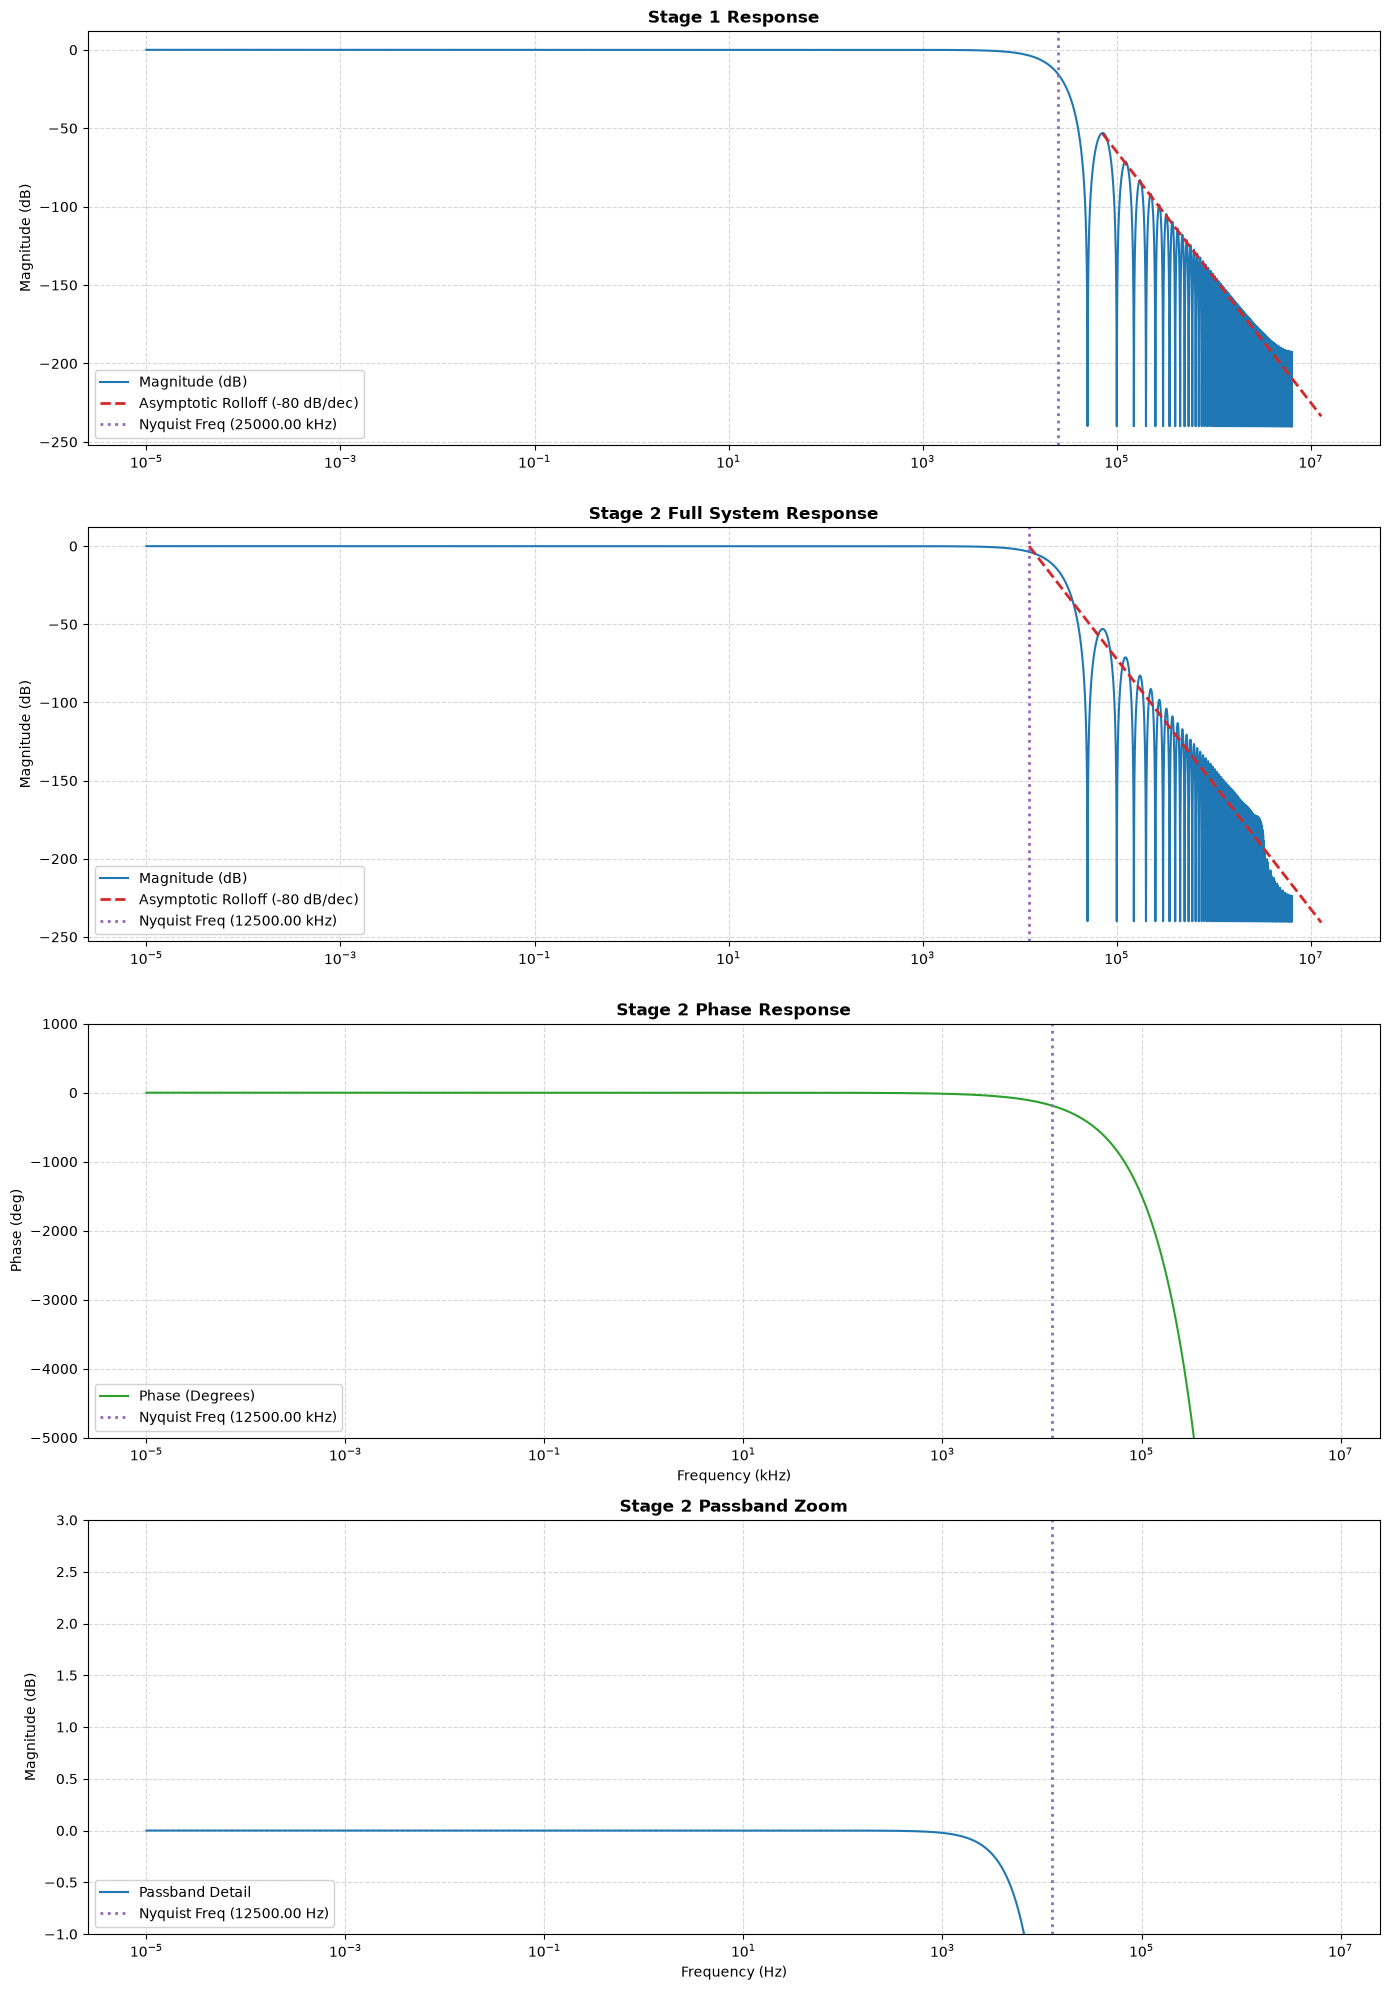

In [108]:
decimator.plot_total_tf()

In [109]:
class DeltaSigmaModulator:
    def __init__(self, order=1, output_format='bipolar'):
        """
        1-Bit Delta-Sigma Modulator (PDM Bitstream Generator).
        
        Parameters:
        order (int): Modulator order (1 or 2).
        output_format (str): 'bipolar' for output values in {-1, +1}
                             'unipolar' for output values in {0, 1}
        """
        if order not in [1, 2, 3]:
            raise ValueError("Order must be either 1 or 2 or 3.")
        if output_format not in ['bipolar', 'unipolar']:
            raise ValueError("output_format must be 'bipolar' or 'unipolar'.")
            
        self.order = order
        self.output_format = output_format

    # def modulate(self, input_signal):
    #     """
    #     Converts a high-resolution input signal into a 1-bit PDM stream.
        
    #     Parameters:
    #     input_signal (array-like): Input array. 
    #                               If 'bipolar', values should be scaled to [-1.0, +1.0].
    #                               If 'unipolar', values should be scaled to [0.0, 1.0].
        
    #     Returns:
    #     np.ndarray (int64): 1-bit bitstream array.
    #     """
    #     x = np.asarray(input_signal, dtype=np.float64)
    #     N_samples = len(x)
    #     bitstream = np.zeros(N_samples, dtype=np.int64)
        
    #     # Internal state variables for integrators
    #     v1 = 0.0
    #     v2 = 0.0
    #     v3 = 0.0
    #     feedback = 0.0

    #     if self.output_format == 'bipolar':
    #         # Expected input range: [-1, +1]
    #         for n in range(N_samples):
    #             # Delta stage (error calculation) & Sigma stage (integrators)
    #             if self.order == 1:
    #                 v1 = v1 + (x[n] - feedback)
    #                 quantizer_in = v1
    #             elif self.order == 2:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 quantizer_in = v2
    #             elif self.order == 3:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 v3 = v3 + (v2 - feedback)
    #                 quantizer_in = v3

    #             # 1-bit Quantizer (Threshold at 0)
    #             bitstream[n] = 1 if quantizer_in >= 0 else -1
    #             feedback = float(bitstream[n])

    #     elif self.output_format == 'unipolar':
    #         # Expected input range: [0, 1]
    #         for n in range(N_samples):
    #             if self.order == 1:
    #                 v1 = v1 + (x[n] - feedback)
    #                 quantizer_in = v1
    #             elif self.order == 2:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 quantizer_in = v2
    #             elif self.order == 3:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 v3 = v3 + (v2 - feedback)
    #                 quantizer_in = v3

    #             # 1-bit Quantizer (Threshold at 0.5)
    #             bitstream[n] = 1 if quantizer_in >= 0.5 else 0
    #             feedback = float(bitstream[n])

    def modulate(self, input_signal):
        x = np.asarray(input_signal, dtype=np.float64)
        N_samples = len(x)
        bitstream = np.zeros(N_samples, dtype=np.int64)
        
        # State variables for 3 integrators
        v1, v2, v3 = 0.0, 0.0, 0.0

        if self.output_format == 'bipolar':
            # Signal Range: [-0.6, +0.6]
            feedback = 0.0
            for n in range(N_samples):
                err = x[n] - feedback
                
                if self.order == 1:
                    v1 += err
                    quantizer_in = v1
                elif self.order == 2:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    quantizer_in = v2
                elif self.order == 3:
                    # Textbook 3rd-Order CIFF Loop Coefficients
                    # Integrator gains: a1=0.5, a2=0.5, a3=0.5
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    v3 += 0.5 * v2
                    # Feedforward weights: c1=1.0, c2=0.6, c3=0.15
                    quantizer_in = 1.0 * v1 + 0.6 * v2 + 0.15 * v3

                # 1-bit Quantizer (Threshold at 0)
                bit = 1 if quantizer_in >= 0 else -1
                bitstream[n] = bit
                feedback = float(bit)

        elif self.output_format == 'unipolar':
            # Signal Range: [0.1, 0.9] (Centered at 0.5)
            feedback = 0.5
            for n in range(N_samples):
                err = x[n] - feedback
                
                if self.order == 1:
                    v1 += err
                    quantizer_in = v1
                elif self.order == 2:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    quantizer_in = v2
                elif self.order == 3:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    v3 += 0.5 * v2
                    quantizer_in = 1.0 * v1 + 0.6 * v2 + 0.15 * v3

                # 1-bit Quantizer
                bit = 1 if quantizer_in >= 0 else 0
                bitstream[n] = bit
                feedback = 1.0 if bit == 1 else 0.0

        return bitstream

        # return bitstream

# class DeltaSigmaModulator:
#     def __init__(self, order=3, osr=64, output_format='bipolar', opt=1, H_inf=1.5):
#         """
#         Parameterizable Delta-Sigma Modulator powered by python-deltasigma.
        
#         Parameters:
#         order (int): Modulator/NTF order (1, 2, 3, 4, 5, etc.)
#         osr (int): Oversampling Ratio (Decimation factor R)
#         output_format (str): 'bipolar' ({-1, +1}) or 'unipolar' ({0, 1})
#         opt (int): NTF zero optimization (0 = all zeros at z=1, 1 = optimized zeros in signal band)
#         H_inf (float): Maximum NTF gain (Lee's criterion stability limit, default 1.5)
#         """
#         self.order = order
#         self.osr = osr
#         self.output_format = output_format
        
#         # 1. Synthesize an optimal Noise Transfer Function (NTF) using python-deltasigma
#         # This guarantees stability for high-order loops (like 3rd order)
#         self.ntf = ds.synthesizeNTF(order=order, OSR=osr, opt=opt, H_inf=H_inf)

#     def modulate(self, input_signal):
#         """
#         Converts high-resolution input array into a 1-bit PDM stream.
        
#         Parameters:
#         input_signal (array-like): Input signal.
#                                   For 'bipolar': range within [-0.6, +0.6]
#                                   For 'unipolar': range within [0.2, 0.8]
        
#         Returns:
#         np.ndarray (int64): 1-bit bitstream array.
#         """
#         u = np.asarray(input_signal, dtype=np.float64)
        
#         if self.output_format == 'unipolar':
#             # python-deltasigma expects [-1, +1] bipolar signals for 2-level quantizers.
#             # Convert input [0, 1] range to [-1, +1] range for simulation
#             u_bipolar = 2.0 * u - 1.0
            
#             # 2. Simulate the DSM using python-deltasigma engine (nlev = 2 levels)
#             v, xn, xmax, y = ds.simulateDSM(u_bipolar, self.ntf, nlev=2)
            
#             # Map output back from {-1, +1} to {0, 1}
#             bitstream = np.where(v >= 0, 1, 0).astype(np.int64)
            
#         else: # 'bipolar'
#             # 2. Simulate 1-bit DSM directly
#             v, xn, xmax, y = ds.simulateDSM(u, self.ntf, nlev=2)
#             bitstream = np.round(v).astype(np.int64)
            
#         return bitstream

In [110]:
t_high = np.arange(0, duration, 1.0 / fs_high)
input_sine = 0.5 + 0.001 * np.sin(2 * np.pi * f_signal * t_high + phi_rad)

In [111]:
dsm = DeltaSigmaModulator(order=3, output_format='unipolar')
bitstream = dsm.modulate(input_sine)

stage 1 p-p value: (np.float64(0.001392), np.float64(0.500766), np.float64(0.499374))
stage 2 p-p value: (np.float64(0.001894), np.float64(0.501042), np.float64(0.499148))


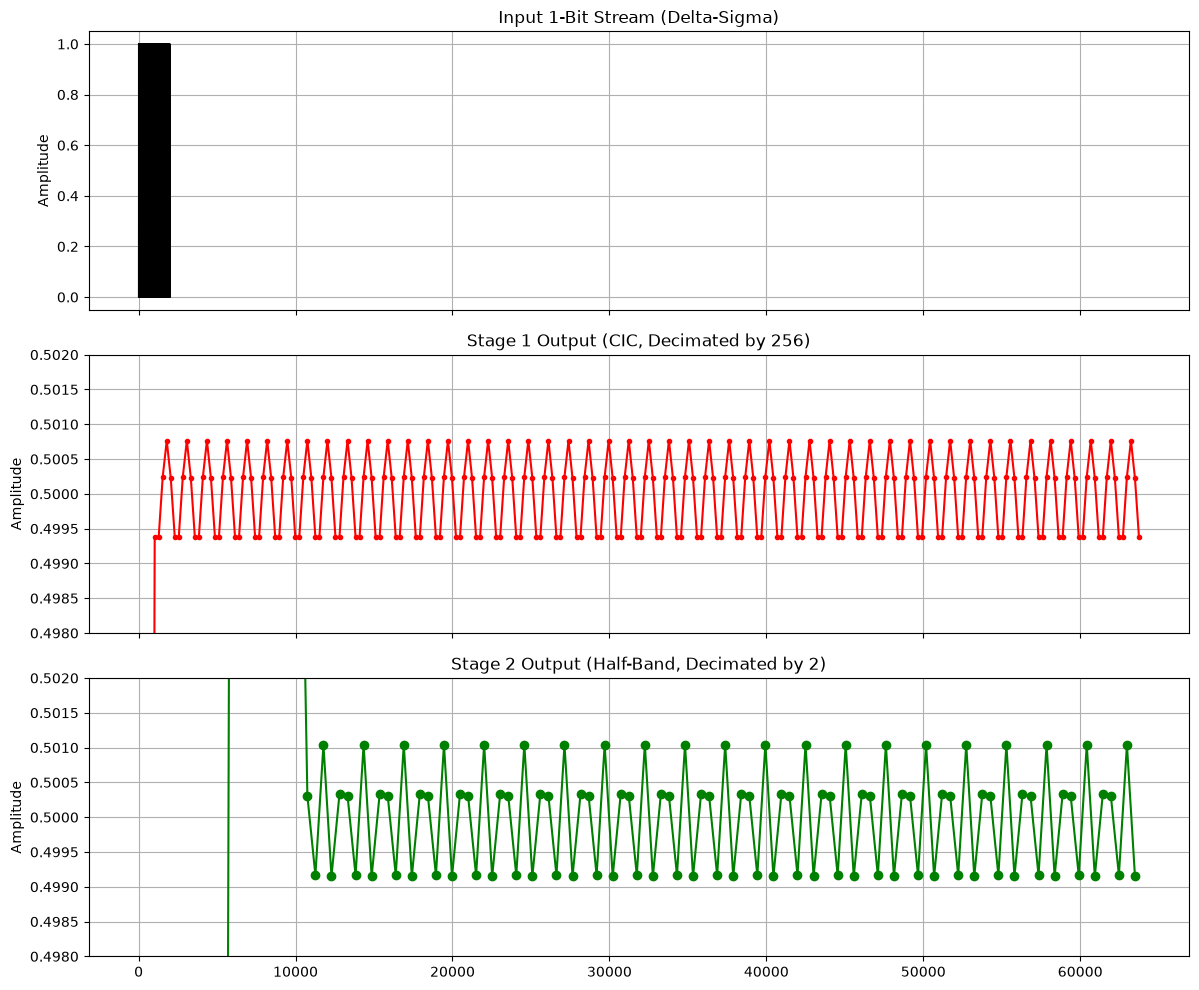

In [112]:
decimator.process_and_plot(bitstream=bitstream)